# Setup


In [1]:
import numpy as np
import pandas as pd
import pathlib
import pickle
import json
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from tensorflow.keras.models import load_model

warnings.filterwarnings('ignore')

# Definisikan Konstanta
LOOKBACK = 60
PROCESSED_DIR = pathlib.Path('../data/processed')
MODELS_DIR = pathlib.Path('../models')
FIGURES_DIR = pathlib.Path('../reports/figures')

# Buat direktori jika belum ada
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load Data Test
X_test = np.load(PROCESSED_DIR / 'X_test.npy')
y_test = np.load(PROCESSED_DIR / 'y_test.npy')

# Load Scaler Target
with open(MODELS_DIR / 'scaler_y.pkl', 'rb') as f:
    scaler_y = pickle.load(f)

# Load Model Deep Learning (JANGAN training ulang)
model_lstm = load_model(MODELS_DIR / 'lstm_antam.h5', compile=False)
model_gru = load_model(MODELS_DIR / 'gru_antam.h5', compile=False)
model_gru_hybrid = load_model(MODELS_DIR / 'gru_residual_antam.h5', compile=False)
with open(MODELS_DIR / 'baseline_model.pkl', 'rb') as f:
    model_baseline = pickle.load(f)

# Load Hasil Metrik
with open(MODELS_DIR / 'results_summary.json', 'r') as f:
    results_summary = json.load(f)

# Load DataFrame Cleaned untuk mendapatkan index waktu (Tanggal)
df_clean = pd.read_csv(PROCESSED_DIR / 'data_antam_clean.csv')
df_clean['Tanggal'] = pd.to_datetime(df_clean['Tanggal'])
df_clean.set_index('Tanggal', inplace=True)

# Ambil index tanggal khusus test set (sesuai panjang y_test = 236 baris terakhir)
test_dates = df_clean.index[-len(y_test):]

# Inverse Transform y_test ke skala Rupiah asli
y_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

print(f"Data X_test dimuat dengan shape: {X_test.shape}")
print(f"Data y_test dimuat dengan shape: {y_test.shape}")
print("Model LSTM, GRU, Scaler, dan Results Summary berhasil dimuat.")


Data X_test dimuat dengan shape: (236, 60, 11)
Data y_test dimuat dengan shape: (236,)
Model LSTM, GRU, Scaler, dan Results Summary berhasil dimuat.


# Hitung dan Rekap Metrik Evaluasi


In [2]:
# Prediksi model Baseline (di-load dari npy)
X_test_2d = X_test.reshape(X_test.shape[0], -1)
y_pred_baseline_scaled = model_baseline.predict(X_test_2d)
y_pred_baseline = scaler_y.inverse_transform(y_pred_baseline_scaled.reshape(-1, 1)).flatten()
y_pred_hybrid_residual_scaled = model_gru_hybrid.predict(X_test).flatten()
y_pred_hybrid_scaled = y_pred_baseline_scaled + y_pred_hybrid_residual_scaled
y_pred_hybrid = scaler_y.inverse_transform(y_pred_hybrid_scaled.reshape(-1, 1)).flatten()

# Prediksi Deep Learning pada test set & Inverse Transform
y_pred_lstm_scaled = model_lstm.predict(X_test)
y_pred_gru_scaled = model_gru.predict(X_test)
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()
y_pred_gru = scaler_y.inverse_transform(y_pred_gru_scaled).flatten()

# Fungsi pembantu untuk kalkulasi metrik
def calculate_metrics(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE (%)': mean_absolute_percentage_error(y_true, y_pred) * 100
    }

# Hitung metrik masing-masing model
metrics_baseline = calculate_metrics(y_actual, y_pred_baseline)
metrics_lstm = calculate_metrics(y_actual, y_pred_lstm)
metrics_gru = calculate_metrics(y_actual, y_pred_gru)
metrics_hybrid = calculate_metrics(y_actual, y_pred_hybrid)

# Buat DataFrame
df_metrics = pd.DataFrame({
    'Model': ['Baseline', 'LSTM', 'GRU', 'Hybrid'],
    'RMSE (Rp)': [metrics_baseline['RMSE'], metrics_lstm['RMSE'], metrics_gru['RMSE'], metrics_hybrid['RMSE']],
    'MAE (Rp)': [metrics_baseline['MAE'], metrics_lstm['MAE'], metrics_gru['MAE'], metrics_hybrid['MAE']],
    'MAPE (%)': [metrics_baseline['MAPE (%)'], metrics_lstm['MAPE (%)'], metrics_gru['MAPE (%)'], metrics_hybrid['MAPE (%)']]
})

print("=== Tabel Metrik Final (X_test) ===")
display(df_metrics.style.format({
    'RMSE (Rp)': '{:,.3f}',
    'MAE (Rp)': '{:,.3f}',
    'MAPE (%)': '{:.2f}%'
}))


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
=== Tabel Metrik Final (X_test) ===


,Model,RMSE (Rp),MAE (Rp),MAPE (%)
0,Baseline,147.244,111.576,3.26%
1,LSTM,532.998,475.340,13.46%
2,GRU,313.233,265.556,7.53%
3,Hybrid,147.603,111.854,3.27%


# Analisis Error Distribution


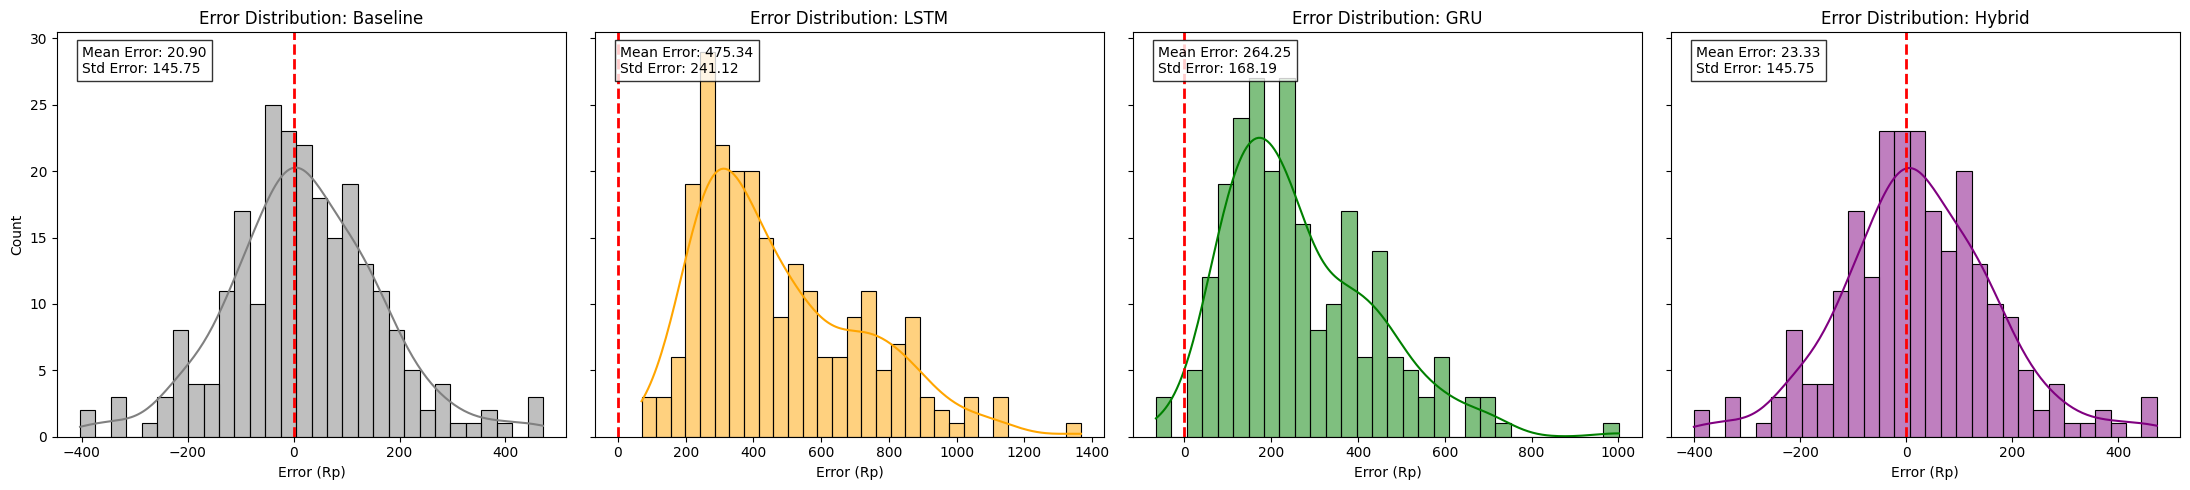

In [3]:
# Hitung Error Residual (Aktual - Prediksi)
err_baseline = y_actual - y_pred_baseline
err_lstm = y_actual - y_pred_lstm
err_gru = y_actual - y_pred_gru
err_hybrid = y_actual - y_pred_hybrid

# Plotting Error Distribution
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)

# Baseline
sns.histplot(err_baseline, bins=30, kde=True, ax=axes[0], color='gray')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Error Distribution: Baseline')
axes[0].set_xlabel('Error (Rp)')
axes[0].text(0.05, 0.9, f"Mean Error: {err_baseline.mean():.2f}\nStd Error: {err_baseline.std():.2f}", 
             transform=axes[0].transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

# LSTM
sns.histplot(err_lstm, bins=30, kde=True, ax=axes[1], color='orange')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Error Distribution: LSTM')
axes[1].set_xlabel('Error (Rp)')
axes[1].text(0.05, 0.9, f"Mean Error: {err_lstm.mean():.2f}\nStd Error: {err_lstm.std():.2f}", 
             transform=axes[1].transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

# GRU
sns.histplot(err_gru, bins=30, kde=True, ax=axes[2], color='green')
axes[2].axvline(0, color='red', linestyle='--', linewidth=2)
axes[2].set_title('Error Distribution: GRU')
axes[2].set_xlabel('Error (Rp)')
axes[2].text(0.05, 0.9, f"Mean Error: {err_gru.mean():.2f}\nStd Error: {err_gru.std():.2f}", 
             transform=axes[2].transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))


# Hybrid
sns.histplot(err_hybrid, bins=30, kde=True, ax=axes[3], color='purple')
axes[3].axvline(0, color='red', linestyle='--', linewidth=2)
axes[3].set_title('Error Distribution: Hybrid')
axes[3].set_xlabel('Error (Rp)')
axes[3].text(0.05, 0.9, f"Mean Error: {err_hybrid.mean():.2f}\nStd Error: {err_hybrid.std():.2f}", 
             transform=axes[3].transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'error_distribution.png')
plt.show()


# Analisis Error Terhadap Waktu


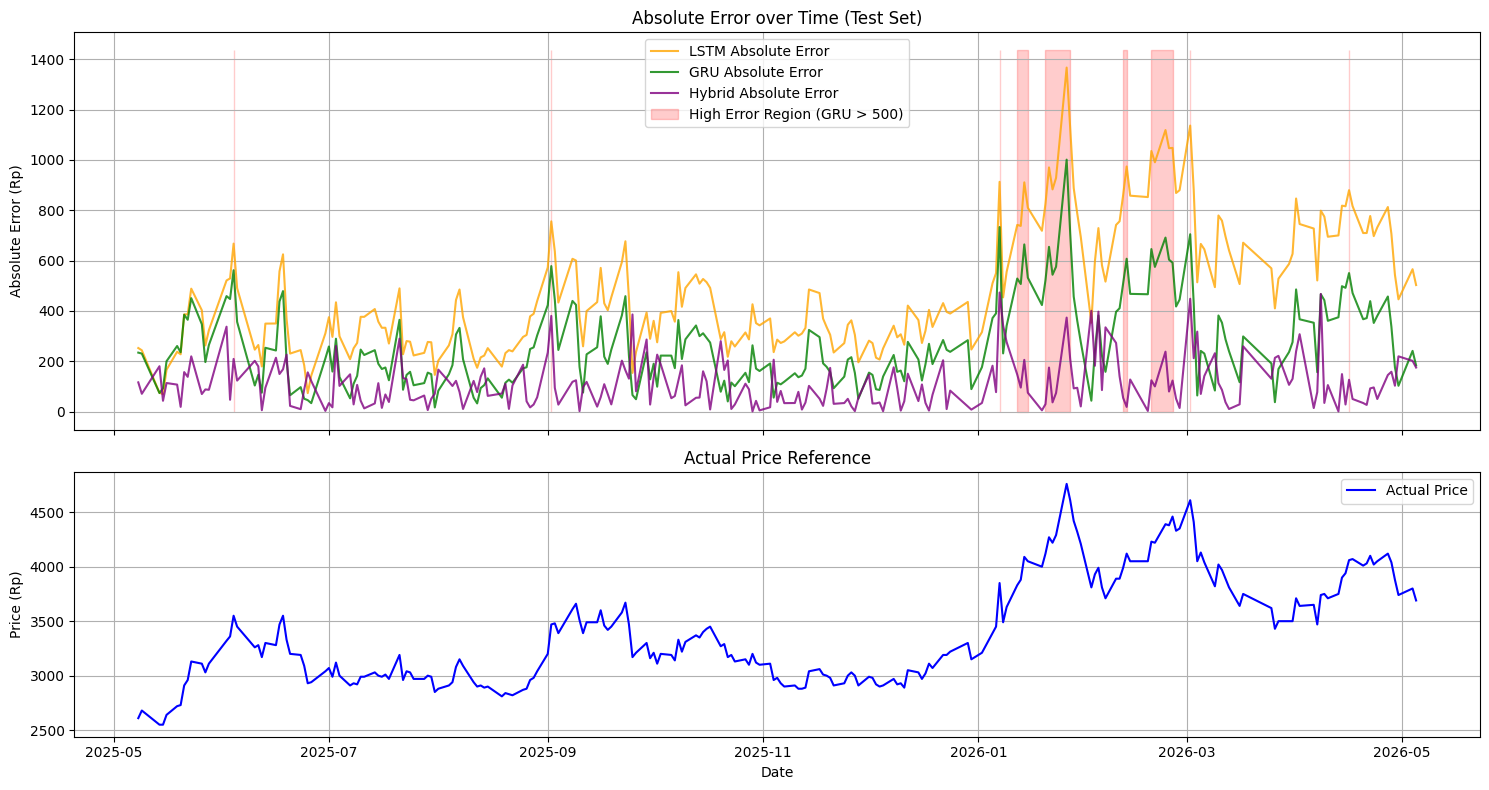

In [4]:
# Hitung Absolute Error
abs_err_lstm = np.abs(err_lstm)
abs_err_gru = np.abs(err_gru)
abs_err_hybrid = np.abs(err_hybrid)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={'height_ratios': [1.5, 1]})

# Subplot 1: Absolute Error
ax1.plot(test_dates, abs_err_lstm, color='orange', alpha=0.8, label='LSTM Absolute Error')
ax1.plot(test_dates, abs_err_gru, color='green', alpha=0.8, label='GRU Absolute Error')
ax1.plot(test_dates, abs_err_hybrid, color='purple', alpha=0.8, label='Hybrid Absolute Error')

# Tandai periode di mana error GRU > 500 dengan shading merah
high_error_mask = abs_err_gru > 500
ax1.fill_between(test_dates, 0, ax1.get_ylim()[1], where=high_error_mask, 
                 color='red', alpha=0.2, label='High Error Region (GRU > 500)')

ax1.set_title('Absolute Error over Time (Test Set)')
ax1.set_ylabel('Absolute Error (Rp)')
ax1.legend()
ax1.grid(True)

# Subplot 2: Harga Aktual sebagai Referensi
ax2.plot(test_dates, y_actual, color='blue', linewidth=1.5, label='Actual Price')
ax2.set_title('Actual Price Reference')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price (Rp)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'error_vs_time.png')
plt.show()


# Prediksi vs Aktual (Final)


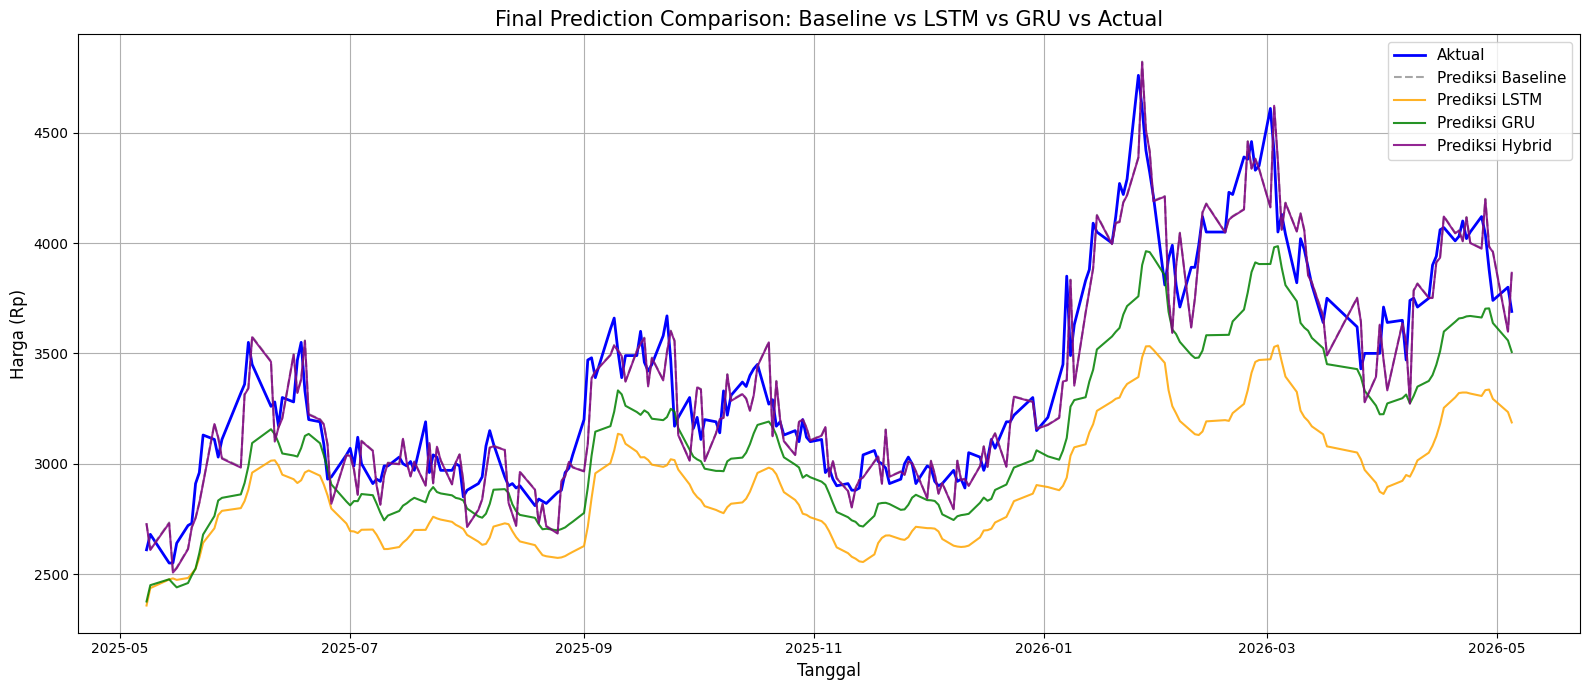

In [5]:
plt.figure(figsize=(16, 7))

# Plot Aktual vs Prediksi
plt.plot(test_dates, y_actual, color='blue', linewidth=2, label='Aktual')
plt.plot(test_dates, y_pred_baseline, color='gray', linestyle='--', alpha=0.7, label='Prediksi Baseline')
plt.plot(test_dates, y_pred_lstm, color='orange', alpha=0.85, label='Prediksi LSTM')
plt.plot(test_dates, y_pred_gru, color='green', alpha=0.85, label='Prediksi GRU')
plt.plot(test_dates, y_pred_hybrid, color='purple', alpha=0.85, label='Prediksi Hybrid')

plt.title('Final Prediction Comparison: Baseline vs LSTM vs GRU vs Actual', fontsize=15)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga (Rp)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_prediction_comparison.png')
plt.show()
